In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


Load Dataset

In [2]:

df = pd.read_csv("Orders.csv")

df.head()


,order_date,Sales_QTY,Sales_amount,currency,User_id,Restaurant_id
0,2017-10-10,100,41241,INR,49226,567335.0
1,2018-05-08,3,-1,INR,77359,531342.0
2,2018-04-06,1,875,INR,5321,158203.0
3,2018-04-11,1,583,INR,21343,187912.0
4,2018-06-18,6,7176,INR,75378,543530.0


Dataset Basic Overview

In [ ]:
df.shape     


(150281, 6)

In [4]:
df.info()       # datatypes & missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150281 entries, 0 to 150280
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_date     150281 non-null  object 
 1   Sales_QTY      150281 non-null  int64  
 2   Sales_amount   150281 non-null  int64  
 3   currency       150281 non-null  object 
 4   User_id        150281 non-null  int64  
 5   Restaurant_id  148664 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.9+ MB


In [5]:
df.columns      # column names


Index(['order_date', 'Sales_QTY', 'Sales_amount', 'currency', 'User_id',
       'Restaurant_id'],
      dtype='object')

Statistical Summary

In [6]:
df.describe()


,Sales_QTY,Sales_amount,User_id,Restaurant_id
count,150281.000000,1.502810e+05,150281.000000,148664.000000
mean,16.264997,6.564802e+03,49969.366553,363433.090513
std,114.761496,2.991743e+04,28902.241989,167889.871825
min,1.000000,-1.000000e+00,1.000000,211.000000
25%,1.000000,1.710000e+02,24826.000000,233136.750000
50%,1.000000,5.090000e+02,49951.000000,412597.500000
75%,7.000000,3.000000e+03,75084.000000,502200.500000
max,14049.000000,1.510944e+06,99999.000000,581031.000000


Missing Values Analysis

In [7]:
df.isnull().sum()


order_date          0
Sales_QTY           0
Sales_amount        0
currency            0
User_id             0
Restaurant_id    1617
dtype: int64

Duplicate Records

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.dtypes

order_date        object
Sales_QTY          int64
Sales_amount       int64
currency          object
User_id            int64
Restaurant_id    float64
dtype: object

Separate Numerical & Categorical Columns

In [10]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['Sales_QTY', 'Sales_amount', 'User_id', 'Restaurant_id'], dtype='object')
Categorical Columns: Index(['order_date', 'currency'], dtype='object')


Univariate Analysis

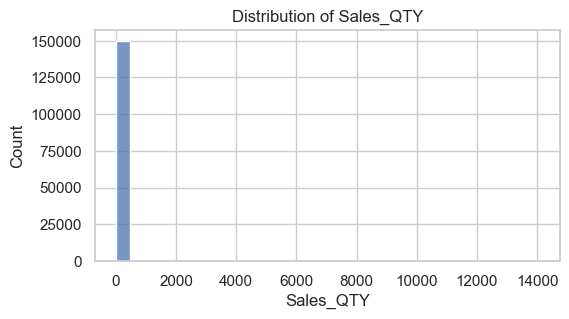

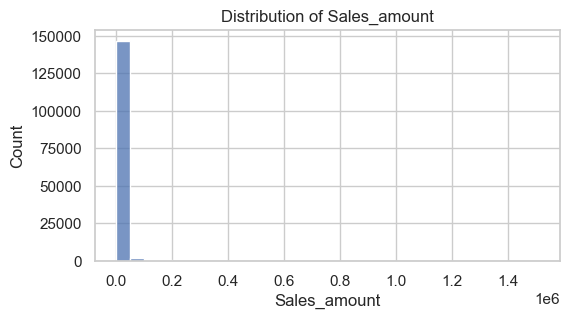

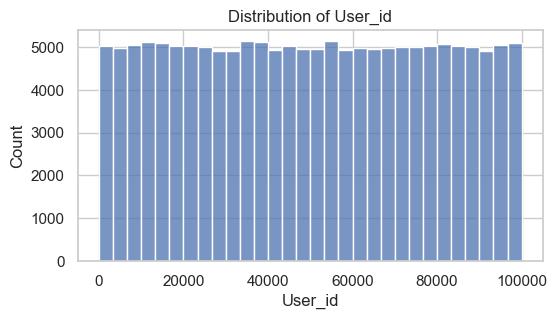

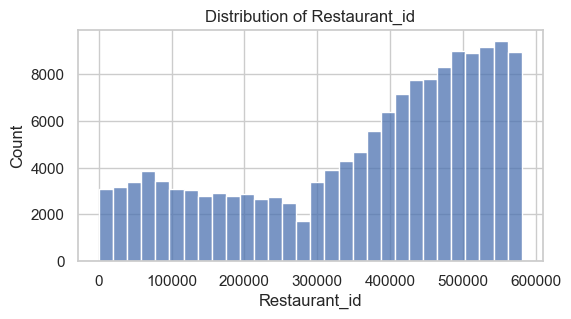

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()


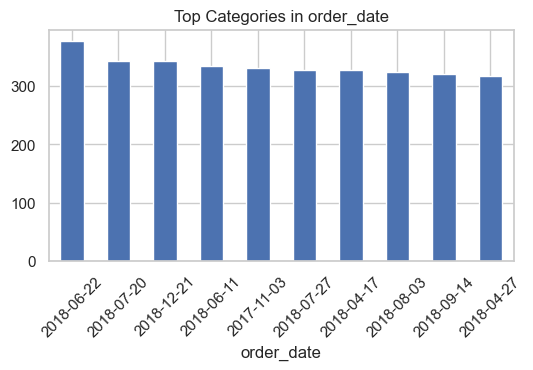

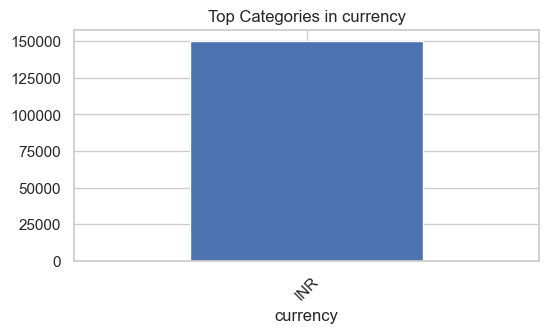

In [12]:
for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()


Bivariate Analysis

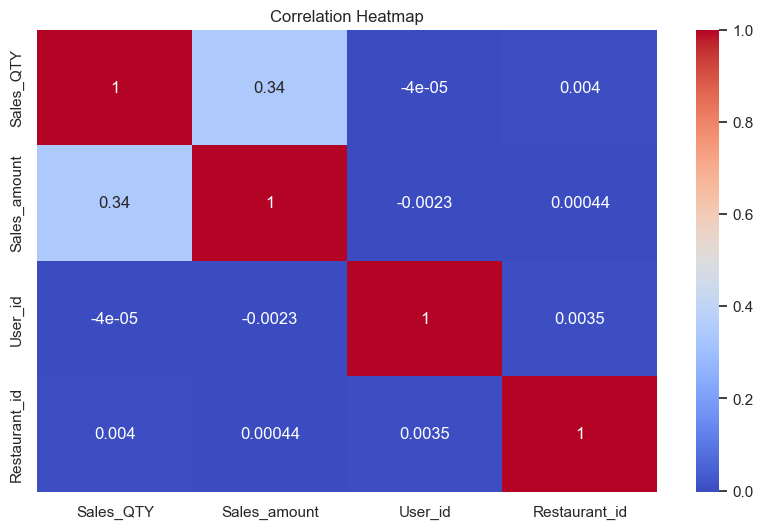

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Outlier Detection

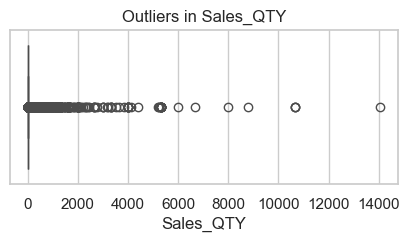

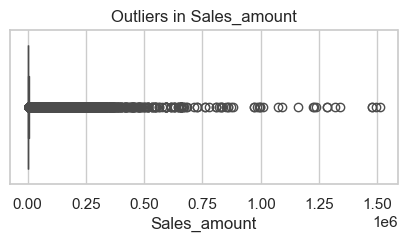

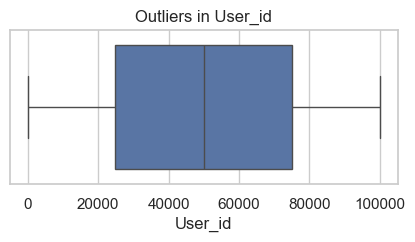

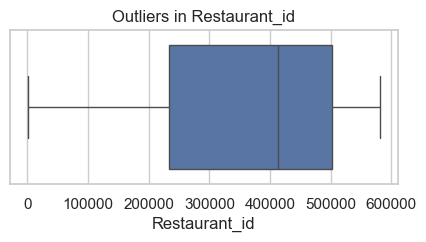

In [15]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()
